<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>
<h1><center>Python Foundations - Week 4</center></h1>

<center><img src="https://cdn.pixabay.com/photo/2018/03/06/08/31/drone-3202860_1280.jpg" width="720"/></center>

<center><font size=5>Product Reviews Sentiment Analysis </center></font>

## Problem Statement

### Business Context

In the rapidly evolving landscape of e-commerce, customer reviews play a pivotal role in shaping the perception of products and influencing purchasing decisions. All businesses recognize the significance of understanding customer sentiment and extracting valuable insights from the vast pool of customer reviews to drive decisions. The inability to actively track customer feedback can result in significant challenges for businesses. Negative sentiments expressed by customers become crucial to track and resolve as they can lead to several detrimental effects, including:

1. **Customer Churn:** Unaddressed negative sentiment can lead to customer dissatisfaction and the potential loss of loyal customers. This may result in customers opting for alternative platforms for their future purchases, impacting long-term revenue and market share.

2. **Reputation Damage:** The persistence of negative sentiment, if not effectively managed, can tarnish the reputation of the business. Potential customers may be dissuaded from making purchases on the platform due to concerns raised in negative reviews, affecting brand loyalty and trust.

3. **Financial Implications:** Negative sentiment can lead to a decline in sales, impacting profitability. Discouraged by negative feedback, potential customers may choose competitors, resulting in direct financial repercussions for the company.

### Problem Definition

A rapidly growing e-commerce platform specializing in electronic gadgets collects customer feedback through multiple channels, such as product review forms, surveys, and social media platforms. Following a 200% growth in their customer base over the past three years, the business has recently observed a ~25% increase in feedback volume within the last six months.

Previously relying on manual tracking and analysis, the surge in feedback has exceeded their capacity to manage it effectively. To address this, the organization aims to implement a scalable, automated solution that employs a **lexicon-based sentiment analyzer**. The objective is to develop a model that can efficiently assess and categorize customer feedback into positive, negative, or neutral sentiments by analyzing product reviews using predefined sentiment dictionaries and rules.

As a Data Scientist, you are provided with a dataset of customer reviews, each labeled with its corresponding sentiment. Your task is to build a sentiment analyzer to parse customer reviews and accurately predict their sentiment.

### Data Dictionary

- **Product ID**: An exclusive identification number for each product

- **Product Review**: Insights and opinions shared by customers about the product

- **Sentiment**: Sentiment associated with the product review, indicating whether the review expresses a positive, negative, or neutral sentiment

## Installing and Importing the necessary libraries

In [ ]:
# to read and manipulate the data
import pandas as pd
import numpy as np
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# to use regular expressions for manipulating text data
import re

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to perform stemming
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Loading the dataset

In [ ]:
# uncomment and run the following lines of code if Google Colab is being used
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
import matplotlib.pyplot as plt

In [8]:
import re

In [9]:
# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to perform stemming
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raghu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raghu\AppData\Roaming\nltk_data...


In [4]:
# loading data into a pandas dataframe
reviews = pd.read_csv(Path("data", "Product_Reviews.csv"))

In [5]:
# creating a copy of the data
data = reviews.copy()

## Data Overview

### Checking the first five rows of the data

In [6]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


### Checking the shape of the dataset

In [ ]:
data.shape

(1007, 3)

* The dataset has 1007 rows and 3 columns.

### Checking for Missing Values

In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* There are no missing values in the data

### Checking for duplicate values

In [ ]:
# checking for duplicate values
data.duplicated().sum()

2

* There are 2 duplicate values in the dataset.
* We'll drop them.

In [ ]:
# dropping duplicate values
data = data.drop_duplicates()

data.duplicated().sum()

0

## Exploratory Data Analysis (EDA)


#### Distribution of sentiments

<Axes: xlabel='Sentiment', ylabel='percent'>

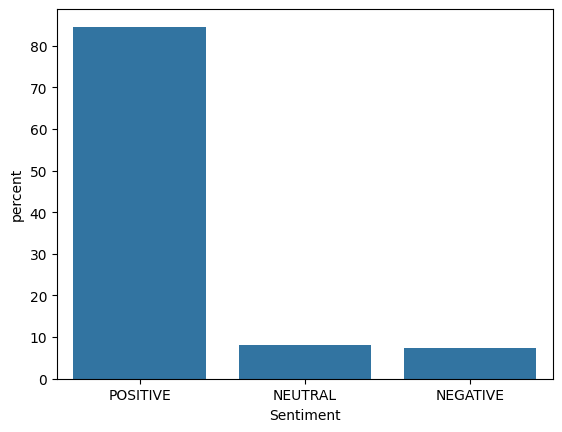

In [ ]:
sns.countplot(data=data, x="Sentiment", stat='percent')

- Majority of the reviews are positive (\~85%), followed by neutral reviews (8%), and then the positive reviews (\~7%)

## Text Preprocessing

### Removing special characters from the text

In [10]:
# defining a function to remove special characters
def remove_special_characters(text):
    # Defining the regex pattern to match non-alphanumeric characters
    pattern = '[^A-Za-z0-9]+'

    # Finding the specified pattern and replacing non-alphanumeric characters with a blank string
    new_text = ''.join(re.sub(pattern, ' ', text))

    return new_text

In [11]:
# Applying the function to remove special characters
data['cleaned_text'] = data['Product Review'].apply(remove_special_characters)

In [12]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['Product Review','cleaned_text']]

,Product Review,cleaned_text
0,I initially had trouble deciding between the p...,I initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,Allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,I am enjoying it so far Great for reading Had ...
3,I bought one of the first Paperwhites and have...,I bought one of the first Paperwhites and have...


- We can observe that the function removed the special characters and retained the alphabets and numbers.

### Lowercasing

In [13]:
# changing the case of the text data to lower case
data['cleaned_text'] = data['cleaned_text'].str.lower()

In [14]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['Product Review','cleaned_text']]

,Product Review,cleaned_text
0,I initially had trouble deciding between the p...,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,i bought one of the first paperwhites and have...


- We can observe that all the text has now successfully been converted to lower case.

### Removing extra whitespace

In [15]:
# removing extra whitespaces from the text
data['cleaned_text'] = data['cleaned_text'].str.strip()

In [16]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['Product Review','cleaned_text']]

,Product Review,cleaned_text
0,I initially had trouble deciding between the p...,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,i bought one of the first paperwhites and have...


### Removing stopwords

* The idea with stop word removal is to **exclude words that appear frequently throughout** all the documents in the corpus.
* Pronouns and articles are typically categorized as stop words.
* The `NLTK` library has an in-built list of stop words and it can utilize that list to remove the stop words from a dataset.

In [17]:
# defining a function to remove stop words using the NLTK library
def remove_stopwords(text):
    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    new_text = ' '.join([word for word in words if word not in stopwords.words('english')])

    return new_text

In [18]:
# Applying the function to remove stop words using the NLTK library
data['cleaned_text_without_stopwords'] = data['cleaned_text'].apply(remove_stopwords)

In [19]:
# checking a couple of instances of cleaned data
data.loc[0:3,['cleaned_text','cleaned_text_without_stopwords']]

,cleaned_text,cleaned_text_without_stopwords
0,i initially had trouble deciding between the p...,initially trouble deciding paperwhite voyage r...
1,allow me to preface this with a little history...,allow preface little history casual reader own...
2,i am enjoying it so far great for reading had ...,enjoying far great reading original fire since...
3,i bought one of the first paperwhites and have...,bought one first paperwhites pleased constant ...


* We observe that all the stopwords have been removed.

### Stemming

Stemming is a language processing method that chops off word endings to find the root or base form of words.

For example,

- Original Word: Jumping, Stemmed Word: Jump
- Original Word: Running, Stemmed Word: Run

The Porter Stemmer is one of the widely-used algorithms for stemming, and it shorten words to their root form by removing suffixes.

In [20]:
# Loading the Porter Stemmer
ps = PorterStemmer()

In [21]:
# defining a function to perform stemming
def apply_porter_stemmer(text):
    # Split text into separate words
    words = text.split()

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    new_text = ' '.join([ps.stem(word) for word in words])

    return new_text

In [22]:
# Applying the function to perform stemming
data['final_cleaned_text'] = data['cleaned_text_without_stopwords'].apply(apply_porter_stemmer)

In [23]:
# checking a couple of instances of cleaned data
data.loc[0:2,['cleaned_text_without_stopwords','final_cleaned_text']]

,cleaned_text_without_stopwords,final_cleaned_text
0,initially trouble deciding paperwhite voyage r...,initi troubl decid paperwhit voyag review less...
1,allow preface little history casual reader own...,allow prefac littl histori casual reader own n...
2,enjoying far great reading original fire since...,enjoy far great read origin fire sinc 2012 fir...


## Lexicon-based Sentiment Analysis


- VADER (Valence Aware Dictionary and Sentiment Reasoner) is a rule-based, open-source tool specifically designed for sentiment analysis on social media text.
- Developed by C.J. Hutto and Eric Gilbert, VADER focuses on identifying the sentiment polarity (positive, neutral, or negative) of short texts.
- It uses a dictionary of words with predefined sentiment scores, considering linguistic nuances like slang, emoticons, and punctuation (e.g., exclamation marks for emphasis).

In [24]:
#Installing the vaderSentiment library
!pip install vaderSentiment -U -q
# !pip install vaderSentiment --upgrade -q

The `SentimentIntensityAnalyzer` class in VADER is a tool that calculates the sentiment intensity of text, giving scores for positive, negative, neutral, and overall (compound) sentiment. It's optimized for social media language and short texts.

- Sentiment ratings were obtained from 10 independent human raters, all pre-screened, trained, and quality-checked to ensure optimal inter-rater reliability.  

- Over 9,000 token features were evaluated on a scale from “[–4] Extremely Negative” to “[4] Extremely Positive,” with an option for “[0] Neutral (or Neither, N/A).”  

- This process resulted in over 7,500 validated lexical features, each with valence scores indicating both sentiment polarity (positive/negative) and sentiment intensity on a scale from –4 to +4.  

- Example valence scores:  
  - “Okay”: 0.9 (Moderate positivity, suggests something is acceptable)
  - “Good”: 1.9 (Positive word, commonly used for approval)
  - “Great”: 3.1 (Very positive word, implies enthusiasm or high quality)
  - “Horrible”: –2.5 (Strongly negative word, indicates something very bad)
  - Frowning emoticon :( : –2.2 (Symbolizes sadness or dissatisfaction)

In [25]:
#Importing the SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [26]:
# creating an instance
sentiment = SentimentIntensityAnalyzer()


- The `make_lex_dict` function in VADER is used to create a dictionary of words and their associated sentiment scores.
- This dictionary is the core of VADER’s sentiment analysis, as it assigns numerical sentiment values to individual words, which the analyzer then uses to calculate the overall sentiment of a given text.
- The dictionary includes scores for words, slang, and emoticons, enabling VADER to handle informal language effectively.

In [27]:
lexicon_dict = sentiment.make_lex_dict()

In [28]:
lexicon_dict['amazing']

2.8

- "amazing" has a high positive score, indicating strong approval or admiration.
- Its intensity reflects a very favorable sentiment, often used to describe something exceptional.

In [29]:
lexicon_dict['worst']

-3.1

- A lexicon score of -3.1 suggests that "worst" is associated with strong negative connotations.
- Words with highly negative scores often convey dissatisfaction, failure, or poor quality.

- Now, let's get the valence scores for the words present in one of the reviews in the dataset.
- Since the lexicon dictionary is limited, not all words will be present. Therefore, we need to check for words that are included in the lexicon dictionary.

In [30]:
# Original product review
review = data['Product Review'].loc[0]
review

"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need to worry about cu

In [31]:
len(review.split(' '))

193

- This review has ~200 words in it.

In [32]:
for i in review.split(' '):
    if i in lexicon_dict:
       print(i,lexicon_dict[i])

trouble -1.7
friends 2.1
fine 0.8
loving 2.9
no -1.2
easy 1.9
hard -0.4
certain 1.1
glad 2.0
worry -1.9
party 1.7


- Out of 193 words, 11 words were part of the lexicon dictionary.
- Words expressing negative emotions or difficulties, like "trouble" and "worry," have strong negative scores.
- Positive relationship words such as "friends" and "loving" carry high positive scores, reflecting warmth and approval.
- Neutral or mildly positive terms like "fine" and "certain" have lower positive scores, suggesting mild positivity or assurance.
- Negative polarity words, like "no" and "hard," have relatively low negative scores, showing less intensity in negativity compared to words like "trouble."

Although we have the valence scores for individual words, we can't determine the review's sentiment without a single score for the entire review/text.

The ***compound score*** combines all individual valence scores into a single score for the entire review/text.

- The compound score is computed by summing the valence scores of each word in the lexicon and then normalized to be between -1 (most extreme negative) and +1 (most extreme positive).

- This is the most useful metric if you want a single unidimensional measure of sentiment for a given review/text.

The `polarity_scores()` method returns a dictionary with sentiment scores, including the compound score, which summarizes the overall sentiment of the text.

In [33]:
comp_score = sentiment.polarity_scores([review])
comp_score

{'neg': 0.008, 'neu': 0.819, 'pos': 0.172, 'compound': 0.9882}

- The review is predominantly neutral, with a high neutral score of 0.819.
- There is a slight positive sentiment, reflected by the positive score of 0.172.
- The compound score of 0.9882 indicates an overall highly positive sentiment.

We know that the compound score lies in the range [-1, 1]. However, we need a decision rule to determine whether the review is positive, negative, or neutral.

- Many decision rules can be used to determine sentiment based on the compound score.
- A common rule is:
  - **Positive** if compound ≥ 0.5 (strong positive sentiment).
  - **Neutral** if -0.5 < compound < 0.5 (balanced or mild sentiment).
  - **Negative** if compound ≤ -0.5 (strong negative sentiment).

- Neutral sentiment is more common in text, so it gets a larger range (-0.5 to 0.5) to capture mild or mixed emotions.
- To classify as positive or negative, we need to be more certain, so the ranges are restricted: positive is set to compound ≥ 0.5, and negative to compound ≤ -0.5. This ensures that only texts with strong, clear sentiment are labeled as positive or negative.

For more information, kindly check [here](https://vadersentiment.readthedocs.io/en/latest/pages/about_the_scoring.html).

In [34]:
def sentiment_comp(x):
    if x >= 0.5:
        return 'POSITIVE'
    elif x <= -0.5:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

In [35]:
sentiment_comp(comp_score['compound'])

'POSITIVE'

- We can observe that the overall sentiment of the review is '**POSITIVE**'

- We have estimated the sentiment of a single review.
- Let's scale it up and estimate the sentiment of all the reviews.
- Until now, we have focused on the original review to gain a clear understanding. From now on, we will work with the cleaned reviews.

In [36]:
data['Sentiment_Predicted']  = data['final_cleaned_text'].apply(lambda x: sentiment_comp(sentiment.polarity_scores(x)['compound']))

In [37]:
data[['Product Review','Sentiment_Predicted']].head(3)

,Product Review,Sentiment_Predicted
0,I initially had trouble deciding between the p...,POSITIVE
1,Allow me to preface this with a little history...,POSITIVE
2,I am enjoying it so far. Great for reading. Ha...,NEUTRAL


- As expected, the sentiment has been estimated for all the reviews.

- **Review 0 (Positive)**: The reviewer expresses clear satisfaction with the Paperwhite over the Voyage, mentioning specific features like the screen, touch sensitivity, and light settings, along with positive emotions like "loving" the device and no regrets.
- **Review 1 (Positive)**: The reviewer is enthusiastic about the Kindle Paperwhite, describing a renewed love for reading, positive experiences with the device, and an overall emotional connection, calling the Kindle a worthy investment.
- **Review 2 (Neutral)**: The reviewer mentions enjoyment of the Paperwhite for reading but provides a more neutral tone, mentioning only a mild positive experience without strong emotional language or specific praise, and no significant issues.

- Now that we have estimated the sentiment for the reviews, we also want to understand how the algorithm performed.

- To do that, we will compare the estimated sentiment with the actual sentiment.
  - One way is to compute the accuracy.

In [38]:
num_correct = (data['Sentiment_Predicted'] == data['Sentiment']).sum()

In [39]:
accuracy = num_correct/data.shape[0]

In [40]:
print("Accuracy ",accuracy)

Accuracy  0.6881827209533267


- We can observe that the accuracy is 69%.
  - This means that the algorithm correctly predicted the sentiment of the review 69% of the time, indicating a moderately strong performance, but there is still room for improvement in its accuracy.
  - This also means that the algorithm incorrectly predicted the sentiment for 31% of the reviews.

In [41]:
num_correct_positive = data[((data['Sentiment'] == 'POSITIVE') & (data['Sentiment_Predicted'] == 'POSITIVE'))]['Product Review'].count()
perc_correct_positive = num_correct_positive / data[(data['Sentiment'] == 'POSITIVE')].shape[0]
perc_correct_positive

np.float64(0.7805164319248826)

In [42]:
num_correct_negative = data[((data['Sentiment'] == 'NEGATIVE') & (data['Sentiment_Predicted'] == 'NEGATIVE'))]['Product Review'].count()
perc_correct_negative = num_correct_negative / data[(data['Sentiment'] == 'NEGATIVE')].shape[0]
perc_correct_negative

np.float64(0.12162162162162163)

In [43]:
num_correct_neutral = data[((data['Sentiment'] == 'NEUTRAL') & (data['Sentiment_Predicted'] == 'NEUTRAL'))]['Product Review'].count()
perc_correct_neutral= num_correct_neutral / data[(data['Sentiment'] == 'NEUTRAL')].shape[0]
perc_correct_neutral

np.float64(0.2345679012345679)

In [44]:
data.Sentiment.value_counts(normalize=True)

Sentiment
POSITIVE    0.846077
NEUTRAL     0.080437
NEGATIVE    0.073486
Name: proportion, dtype: float64

- While the algorithm does pretty good in the positive reviews, it fails to correctly identify large proportions of the neutral and negative reviews.

Let's understand the cases in which the algorithm made mistakes. We will only focus on the two cases below and the same approach can be extended for the other cases.

- Case when the actual sentiment is NEUTRAL and the estimated sentiment is POSITIVE

- Case when the actual sentiment is NEGATIVE and the estimated sentiment is POSITIVE

In [45]:
data[((data['Sentiment']=='NEUTRAL') & (data['Sentiment_Predicted']=='POSITIVE'))]['Product Review'].head(3)

17    The Kindle is my first e-ink reader. I own an ...
26    Like a previous reviewer mentioned it is fabri...
35    Updated 12/8/2014One year in...This review is ...
Name: Product Review, dtype: object

- The lexicon analyzer might interpret this as positive because as per the review, the user enjoys the Kindle's lightness, ease of reading, good contrast, and adjustable font, which improve comfort over physical books. However, it fails to capture the drawbacks shared by the user, like limited store categorization, and occasional Wi-Fi issues, which downgrade the overall reading experience.

- The lexicon analyzer might interpret this as positive due to words like “good quality” and “hard plastic,” which often carry positive connotations. However, the actual sentiment is neutral because the reviewer is simply describing the product's material and fit without strong positive or negative feelings. Words like “not a snug or tight fit” add a hint of disappointment, but this nuance may be missed by the lexicon, causing a mismatch.

- The lexicon analyzer might interpret this as positive due to phrases like "no brainer," "Amazon has been adding clarification," "they're listening," and "improvement," which generally suggest satisfaction. However, the actual sentiment is more neutral because the reviewer highlights limitations around download capabilities and storage assumptions, which impacted their initial expectations. While Amazon’s improvements are appreciated, the overall tone is balanced, noting both benefits and restrictions.

In [46]:
data[((data['Sentiment']=='NEGATIVE') & (data['Sentiment_Predicted']=='POSITIVE'))]['Product Review'].head(3)

114    As the Kids Edition is nothing more than a bas...
153    This is my 4th Kindle since I bought my first ...
196    I already have 2 Roku devices, but thought I w...
Name: Product Review, dtype: object

- The lexicon analyzer might have rated it positively due to the overall tone of the review highlighting the tablet's affordability and practical features like the case and warranty, which are seen as bonuses. However, the negative sentiment towards Freetime (described as "terrible in practice") could have been overshadowed by the focus on the value of the $50 price and the extras.

- The lexicon analyzer may have rated this positively because the review starts with a strong endorsement, noting the Kindle's comfort and improvements over previous models. However, the mention of several frustrations, such as the weak battery cover, issues with accidental page turns, and shorter battery life, may have been seen as minor critiques, not detracting too much from the overall impression.

- The lexicon analyzer likely rated this positively due to the initial mention of the device working fine for Amazon Instant video, suggesting some satisfaction. However, the strong frustration with the lag in the Netflix app and the desire for a refund likely balanced this out, leading to a more mixed or negative sentiment overall.

# Conclusion

- We analyzed the distribution of sentiments of the customers.

- We used different text processing techniques to clean the raw text data.

- We then built a Sentiment Analyzer using a lexicon-based approach.
  - The lexicon-based analyzer achieved 69% accuracy, but there is still room for improvement.
  - It tends to focus on individual words' sentiment rather than considering the broader context.
  - This approach can lead to incorrect predictions in more complex reviews.
  - The lack of contextual understanding affects its ability to accurately assess nuanced opinions.
  - Improvements could be made by incorporating more sophisticated context-aware analysis.

- By pinpointing areas of improvement or concerns raised by customers based on the predictions of the model, the organization can take swift and targeted actions to address issues, minimizing the risk of revenue loss and bolstering customer satisfaction.

- The organization can leverage sentiment categorizations to tailor marketing strategies.
    - Highlighting positive sentiments in promotional material can contribute to a positive brand image.
    - They can use neutral and negative sentiments to make informed decisions around inventory.

<font size=6 color='blue'>Power Ahead</font>
___